# Authors
- Raphael Wäspi (18-918-938)
- Nicolas Huber (16-936-205)

## II - Clustering Coefficient - Coding Exercise (6 points)

For the provided datasets (you can find the dataset files in the Materials/Session 03 folder on OLAT):

1. Plot the average degree of the nearest neighbours knn as a function of the vertices degree.
2. Super impose the same quantity for the randomised network.
Hint: The randomised networks are obtained via multiple edge swaps via the networkx function
nx.algorithms.smallworld.random_reference. Make sure to set the parameter connectivity
= False to have faster execution. If execution is still slow, we provide randomised datasets.)
3. Compute the assortativity coefficient of the real network.
4. Compute the assortativity coefficient of the randomised network.

In [216]:
# Imports
import match as m
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import os
import glob
import re
from tqdm import tqdm
from scipy.stats import pearsonr, spearmanr, kendalltau
import shutil

In [217]:
# Define colors with reduced opacity from a colormap
COLOR_BLUE = 'dodgerblue'
COLOR_RED = 'lightcoral'

# Define max number of k-neighbors
MAX_K = range(1, 10, 1)
RANGE_K = [1, 2, 5, 10, 20, 50, 100, 200]

KNN_RANGE = RANGE_K

# Define the main data directory
OUTPUT_PATH = "./output"

In [218]:
# Prepare output folder

# Delete the entire 'output' directory and its contents
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)

# Create the 'output' directory
os.makedirs(OUTPUT_PATH)

# Define subdirectories
OUTPUT_PATH_AVG_DEGREE = os.path.join(OUTPUT_PATH, "avg_degree")
OUTPUT_PATH_RANDOMIZED = os.path.join(OUTPUT_PATH, "avg_degree_randomized")

# Recreate the subdirectories
os.makedirs(OUTPUT_PATH_AVG_DEGREE)
os.makedirs(OUTPUT_PATH_RANDOMIZED)

### 1. Plot the average degree of the nearest neighbours knn as a function of the vertices degree.

In [219]:
# Define the directory containing the .gml files
directory = 'assignment_1_data'

# Use glob to get a list of all .gml files in the directory
gml_files = glob.glob(os.path.join(directory, '*.gml'))

# Init an empty dictionary for all graphs - the key is the actual name, and the value is the graph data
graphs = {}

# Use tqdm to show a progress bar in Jupyter Notebook
with tqdm(total=len(gml_files), desc="Loading GML Files") as pbar:
    # Loop through the list of .gml files and load them
    for file_path in gml_files:
        with open(file_path, 'r') as file:
            content = file.read()
            
            # Use regex to extract the desired part
            match = re.search(r'/([^/]+)\.gml$', file_path)
            if match:
                graph_name = match.group(1)
                
                # Add to the graph dictionary
                graph = nx.read_gml(file_path)
                graphs[graph_name] = graph
                
                # Print the graph name when each part is finished
                print(f"Finished loading {graph_name}")
                
        pbar.update(1)  # Update the progress bar

Loading GML Files:  22%|██▏       | 2/9 [00:09<00:27,  3.90s/it]

Finished loading graph_AstroPh
Finished loading graph_jazz_collab


Loading GML Files:  56%|█████▌    | 5/9 [00:15<00:08,  2.12s/it]

Finished loading graph_internet
Finished loading graph_game_thrones
Finished loading graph_eu_airlines


Loading GML Files:  67%|██████▋   | 6/9 [00:22<00:10,  3.62s/it]

...

Finished loading graph_facebook


Loading GML Files:  89%|████████▉ | 8/9 [00:33<00:04,  4.54s/it]

Finished loading graph_CondMat


Loading GML Files: 100%|██████████| 9/9 [00:35<00:00,  3.96s/it]

Finished loading graph_chess


In [220]:
# Initialize results dictionary
results = {graph_name: {} for graph_name in graphs.keys()}

In [221]:
print(results)

{'graph_AstroPh': {}, 'graph_jazz_collab': {}, 'graph_internet': {}, 'graph_game_thrones': {}, 'graph_eu_airlines': {}, 'graph_celegansInteractomes': {}, 'graph_facebook': {}, 'graph_CondMat': {}, 'graph_chess': {}}


In [222]:
num_graphs = len(graphs)

In [223]:
# Function to calculate average k-NN degree
def calculate_knn_degree(g, k):
    
    """
    Calculate the average k-NN degree for a given graph.

    Parameters:
    - g (networkx.Graph): The input graph.
    - k (int): The desired minimum number of neighbors for a node to be considered in the calculation.

    Returns:
    - node_degrees (list): List of vertex degrees for nodes meeting the neighbor count criteria (len(neighbors) >= k).
    - average_knn_degrees (list): List of average k-NN degrees corresponding to the selected nodes.

    This function iterates over all nodes in the input graph, extracts their neighbors, and calculates the degrees for these neighbors.
    It then computes the average k-NN degree for each node, considering only nodes with a neighbor count greater than or equal to k.
    The function returns two lists: node_degrees and average_knn_degrees.

    Example:
    node_degrees, average_knn_degrees = calculate_knn_degree(my_graph, 3)
    """
    
    average_knn_degrees = []
    node_degrees = []

     # Iterate over all nodes and extract neighbors
    for node in g.nodes():
        neighbors = list(g.neighbors(node))
         # Calculate degrees for all neighbors and also the average k-NN degree
        if len(neighbors) >= k:
            node_degrees.append(len(neighbors))
            knn_degrees = [g.degree(neighbor) for neighbor in neighbors]
            average_knn_degree = np.mean(knn_degrees)
            average_knn_degrees.append(average_knn_degree)

    return node_degrees, average_knn_degrees

In [224]:
def plot_knn_subplot(graph, k, graph_name, results, output_path, randomized=False):
    # Create a new figure and axis for the subplot
    fig, ax = plt.subplots(figsize=(8, 6))

    # Calculate node degrees and average k-NN degrees
    node_degrees, average_knn_degrees = calculate_knn_degree(g=graph, k=k)

    # Labelling of result entries
    result_degree_y_key = f"Average {k}-NN Degree{' (randomized)' if randomized else ''}"
    result_degree_x_key = f"Average {k}-NN Degree (x){' (randomized)' if randomized else ''}"

    # Append to result dict
    results[graph_name][result_degree_y_key] = average_knn_degrees
    results[graph_name][result_degree_x_key] = node_degrees

    # Plot on the current subplot
    ax.scatter(x=node_degrees, y=average_knn_degrees, color=COLOR_BLUE)
    ax.set_xlabel("Vertex Degree")
    ax.set_ylabel(f"Average {k}-NN Degree")
    ax.set_title(f"Average {k}-NN Degree vs. Vertex Degree{' (randomized)' if randomized else ''}: {graph_name}")
    ax.grid(True)
    
    # Save the current subplot as a separate PNG image
    subplot_filename = os.path.join(output_path, f"subplot_{k}_{graph_name}{'_randomized' if randomized else ''}.png")
    plt.savefig(subplot_filename)
    plt.close()  # Close the current figure to prevent overlapping plots

In [225]:
# Subplots: calculate knn for each graph
for k in RANGE_K:
    for graph_name, graph in graphs.items():
        plot_knn_subplot(graph, k, graph_name, results, OUTPUT_PATH_AVG_DEGREE, False)

In [226]:
def create_main_knn_plot(RANGE_K, num_graphs, graphs, output_path, COLOR_BLUE, randomized = False):
    # Create a grid of subplots with rows for each k value and columns for each graph
    fig, axs = plt.subplots(len(RANGE_K), num_graphs, figsize=(60, 15))
    for j, k in enumerate(RANGE_K):
        for i, (graph_name, g) in enumerate(graphs.items()):

            # Create a new figure and axis for each subplot
            ax = axs[j, i]

            node_degrees, average_knn_degrees = calculate_knn_degree(g=g, k=k)

            # Plot on the current subplot
            ax.scatter(x=node_degrees, y=average_knn_degrees, color=COLOR_BLUE)
            ax.set_xlabel("Vertex Degree")
            ax.set_ylabel(f"Average {k}-NN Degree")
            ax.set_title(f"Average {k}-NN Degree vs. Vertex Degree{' (randomized)' if randomized else ''}: {graph_name}")
            ax.grid(True)

    # Set title
    fig.suptitle(t=f"Average degree of the nearest neighbors knn as a function of the vertices degree{' (randomized)'if randomized else ''}", fontsize=32, )
    

    # Adjust spacing between subplots
    plt.tight_layout()

    # Save the complete plot as a PNG image
    complete_plot_filename = os.path.join(output_path, f"average_degree_for_knn{'_randomized'if randomized else ''}.png")
    plt.savefig(complete_plot_filename)

    plt.show()

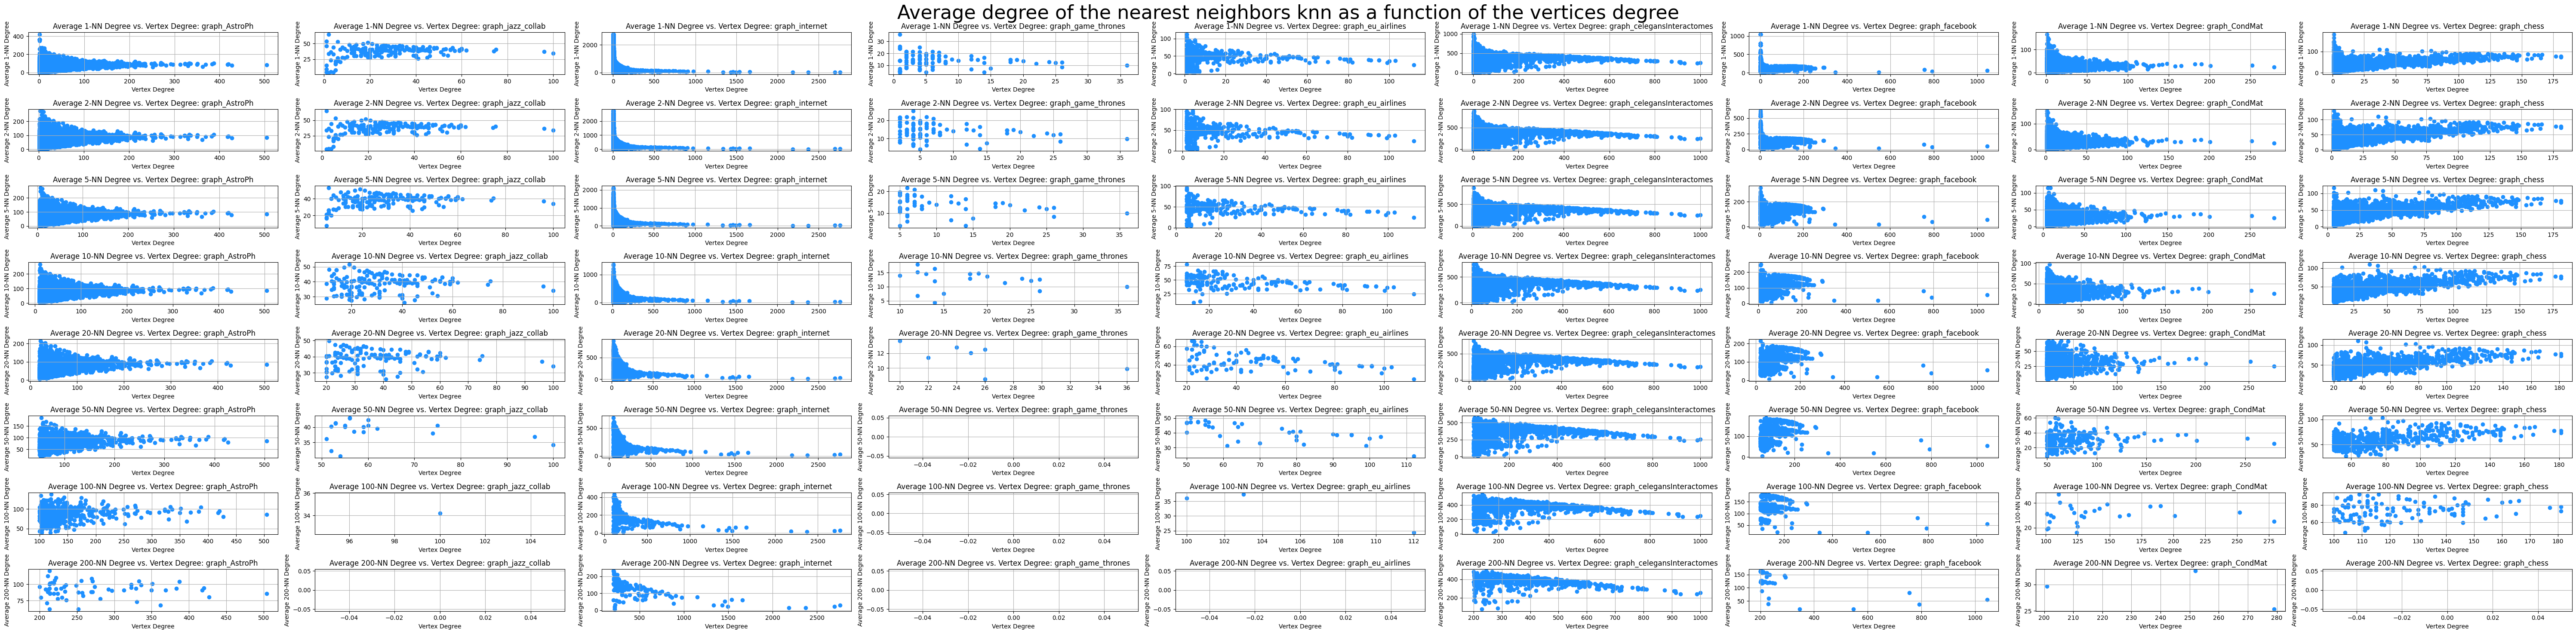

In [227]:
create_main_knn_plot(RANGE_K, num_graphs, graphs, OUTPUT_PATH_AVG_DEGREE, COLOR_BLUE, False)

## 2. Super impose the same quantity for the randomised network.

Hint: The randomised networks are obtained via multiple edge swaps via the networkx function
nx.algorithms.smallworld.random_reference. Make sure to set the parameter connectivity
= False to have faster execution. If execution is still slow, we provide randomised datasets.)

In [228]:
random_graphs = graphs.copy()
SEED = 42

for graph_name, g in random_graphs.items():
    random_graphs[graph_name] = nx.algorithms.smallworld.random_reference(G=g, niter=1, connectivity=False, seed=SEED)
    

In [229]:
num_graphs = len(random_graphs)

In [230]:
# Subplots: calculate knn for each graph
for k in RANGE_K:
    for graph_name, graph in random_graphs.items():
        plot_knn_subplot(graph, k, graph_name, results, OUTPUT_PATH_RANDOMIZED, True)

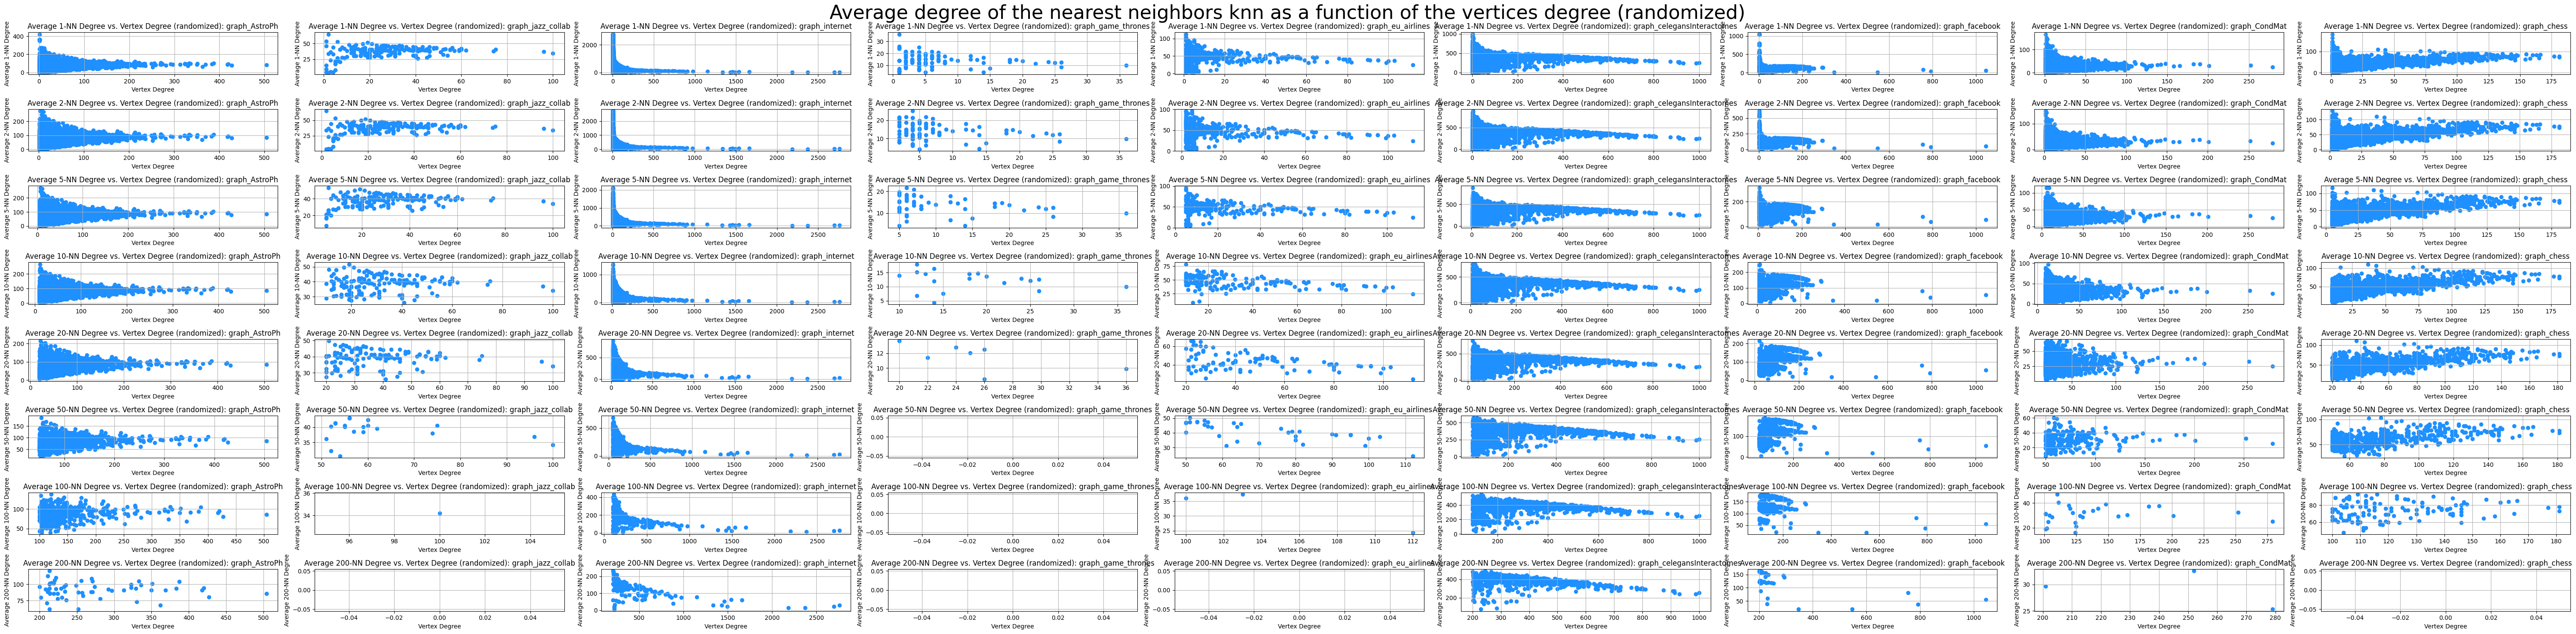

In [231]:
create_main_knn_plot(RANGE_K, num_graphs, graphs, OUTPUT_PATH_RANDOMIZED, COLOR_BLUE, True)

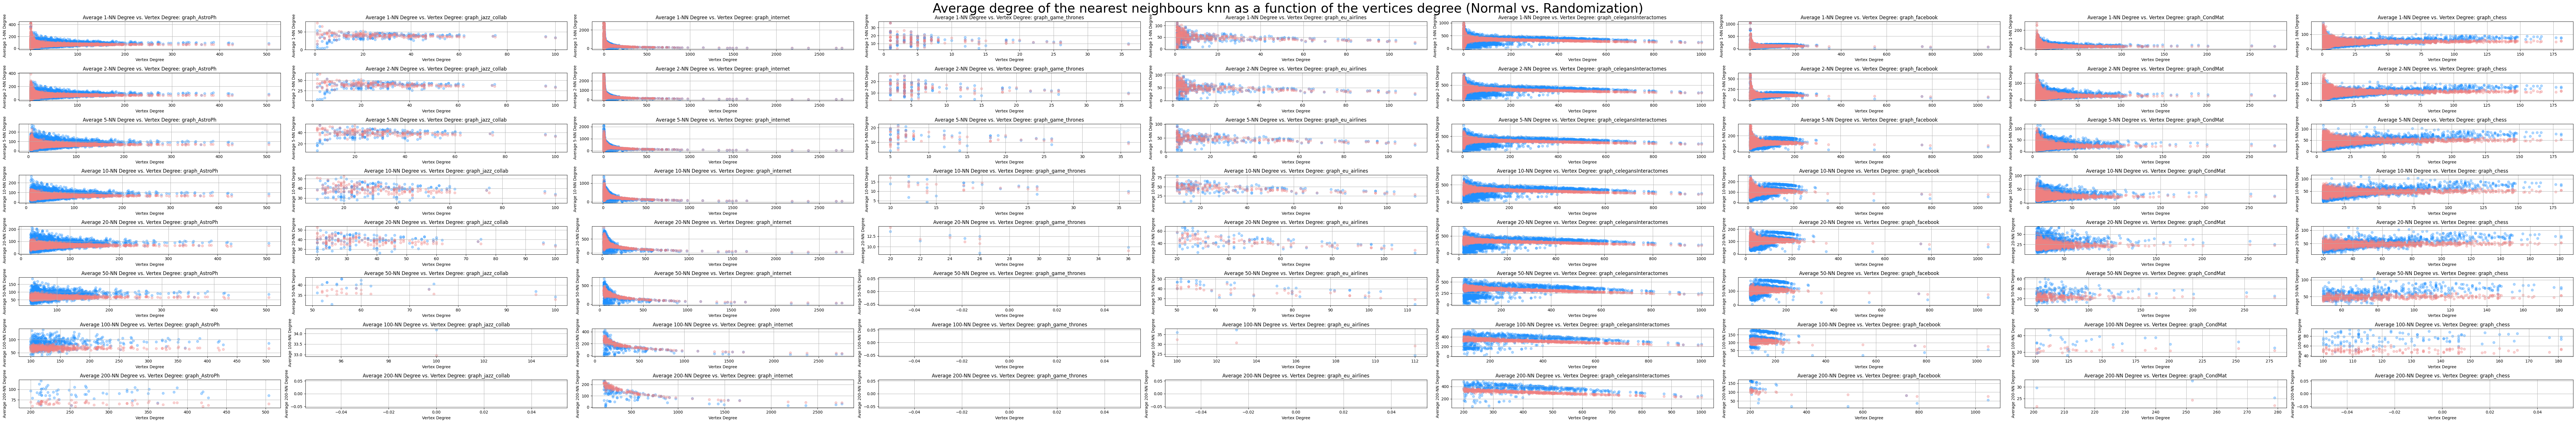

In [232]:
# Create a grid of subplots with rows for each k value and columns for each graph
fig, axs = plt.subplots(len(KNN_RANGE), num_graphs, figsize=(90, 15))

for j, k in enumerate(RANGE_K):
    for i, (graph_name, g) in enumerate(random_graphs.items()):
        
        # Plot on the corresponding subplot
        axs[j, i].scatter(x=results[graph_name][f"Average {k}-NN Degree (x)"], y=results[graph_name][f"Average {k}-NN Degree"], label='normal', color=COLOR_BLUE, alpha=0.35) # Normal
        axs[j, i].scatter(x=results[graph_name][f"Average {k}-NN Degree (x) (randomized)"], y=results[graph_name][f"Average {k}-NN Degree (randomized)"], label='randomized', color=COLOR_RED, alpha=0.35) # Randomized
        axs[j, i].set_xlabel("Vertex Degree")
        axs[j, i].set_ylabel(f"Average {k}-NN Degree")
        axs[j, i].set_title(f"Average {k}-NN Degree vs. Vertex Degree: {graph_name}")
        axs[j, i].grid(True)

# Set title
fig.suptitle(t=f"Average degree of the nearest neighbours knn as a function of the vertices degree (Normal vs. Randomization)", fontsize=32, )


# Adjust spacing between subplots
plt.tight_layout()

# Save the complete plot as a PNG image
complete_plot_randomized_filename = os.path.join(OUTPUT_PATH, f"average_degree_for_knn_super_imposed.png")
plt.savefig(complete_plot_randomized_filename)




## 3. Compute the assortativity coefficient of the real network.

In [233]:
def print_network_assortativity_coefficients(graphs, randomized=False):
    # Calculate the maximum length of network names
    max_name_length = max(len(graph_name) for graph_name in graphs.keys())

    for graph_name, g in graphs.items():
        assortativity_coefficient = nx.degree_assortativity_coefficient(G=g)
        randomized_suffix = " (randomized)" if randomized else ""
        results[graph_name][f"Assortativity Coefficient{randomized_suffix}"] = assortativity_coefficient
        print(f"The network {graph_name:{max_name_length}s}{randomized_suffix} has an Assortativity Coefficient of {assortativity_coefficient:10.4f}")

In [234]:
print_network_assortativity_coefficients(graphs, False)

The network graph_AstroPh              has an Assortativity Coefficient of     0.2013
The network graph_jazz_collab          has an Assortativity Coefficient of     0.0202
The network graph_internet             has an Assortativity Coefficient of    -0.2149
The network graph_game_thrones         has an Assortativity Coefficient of    -0.1308
The network graph_eu_airlines          has an Assortativity Coefficient of    -0.1518
The network graph_celegansInteractomes has an Assortativity Coefficient of     0.1517
The network graph_facebook             has an Assortativity Coefficient of     0.0636
The network graph_CondMat              has an Assortativity Coefficient of     0.1253
The network graph_chess                has an Assortativity Coefficient of     0.3705


## 4. Compute the assortativity coefficient of the randomised network.

In [235]:
print_network_assortativity_coefficients(random_graphs, True)

The network graph_AstroPh              (randomized) has an Assortativity Coefficient of     0.0196
The network graph_jazz_collab          (randomized) has an Assortativity Coefficient of    -0.0906
The network graph_internet             (randomized) has an Assortativity Coefficient of    -0.1976
The network graph_game_thrones         (randomized) has an Assortativity Coefficient of    -0.1701
The network graph_eu_airlines          (randomized) has an Assortativity Coefficient of    -0.2254
The network graph_celegansInteractomes (randomized) has an Assortativity Coefficient of    -0.1613
The network graph_facebook             (randomized) has an Assortativity Coefficient of    -0.0319
The network graph_CondMat              (randomized) has an Assortativity Coefficient of     0.0111
The network graph_chess                (randomized) has an Assortativity Coefficient of     0.0428


In [238]:
def print_network_comparison(results):
    # Determine the maximum length for network names
    max_name_length = max(len(graph_name) for graph_name in results.keys())

    print("Comparison of the assortativity coefficient in normal vs. randomized networks")
    
    for graph_name, res in results.items():
        normal_coefficient = res.get('Assortativity Coefficient', 0.0)
        randomized_coefficient = res.get('Assortativity Coefficient (randomized)', 0.0)
        
        print(f"{graph_name:{max_name_length}s} - Normal: {normal_coefficient:10.4f} Randomized: {randomized_coefficient:10.4f}")

In [239]:
print_network_comparison(results)

Comparison of the assortativity coefficient in normal vs. randomized networks
graph_AstroPh              - Normal:     0.2013 Randomized:     0.0196
graph_jazz_collab          - Normal:     0.0202 Randomized:    -0.0906
graph_internet             - Normal:    -0.2149 Randomized:    -0.1976
graph_game_thrones         - Normal:    -0.1308 Randomized:    -0.1701
graph_eu_airlines          - Normal:    -0.1518 Randomized:    -0.2254
graph_celegansInteractomes - Normal:     0.1517 Randomized:    -0.1613
graph_facebook             - Normal:     0.0636 Randomized:    -0.0319
graph_CondMat              - Normal:     0.1253 Randomized:     0.0111
graph_chess                - Normal:     0.3705 Randomized:     0.0428


- The assortativity coefficient ranges from -1 to 1:

- A positive coefficient (closer to 1) indicates assortative mixing, meaning nodes with similar degrees tend to connect.
- A negative coefficient (closer to -1) indicates disassortative mixing, meaning nodes with dissimilar degrees tend to connect.
- A coefficient near 0 suggests a network with little to no assortative or disassortative mixing, indicating a more random or heterogeneous connection pattern.

## IV - Centralities - Coding Exercise (9 points)

1. Compute degree, closeness, betweenness and eigenvector centrality for each node.
2. Do a scatter plot of each pair of centrality (6 plots total). Compute Pearson, Spearman and Kendall correlation coefficient for each pair and note them on the scatter plots. Hint: Centralities measures are available on NetworkX, while correlation coefficients are available on the module scipy.stats.
3. Repeat point 2 on randomised versions of the graphs provided. Hint: Check point 2 of Exercise 2, for indications on the randomisation function to use in NetworkX.
4. Briefly explain, for the Jazz collaboration network from Gleiser and Danon [2003], what each centrality measure means in practice.

In [ ]:
# Define CENTRALITY_MEASURES
CENTRALITY_MEASURES = ["Degree", "Closeness", "Betweenness", "Eigenvector Centrality"]

In [ ]:
# create result dict for every graph
results_4 = dict.fromkeys(graphs)
for key, value in results_4.items():
    results_4[key] = {}

In [ ]:
# find smallest graph
for name, g in graphs.items():
    print(len(g.nodes()), name)

## 1. Compute degree, closeness, betweenness and eigenvector centrality for each node.

In [ ]:
# Compute different metrics for all nodes in the graph
for i, (graph_name, g) in enumerate(graphs.items()):
    if graph_name in ["graph_jazz_collab", "graph_game_thrones", "graph_eu_airlines"]:
        node_properties = {}
        node_properties["Degree"] = nx.degree_centrality(G=g)
        node_properties["Closeness"] = nx.closeness_centrality(G=g)
        node_properties["Betweenness"] = nx.betweenness_centrality(G=g)
        node_properties["Eigenvector Centrality"] = nx.eigenvector_centrality(G=g)
        results_4[graph_name] = node_properties

In [ ]:
# Remove graphs that are not part of the exercise (e.g., AstroPH, internet, ...)

# Get a list of keys with empty dictionaries
keys_to_remove = [key for key, value in results_4.items() if not bool(value)]

# Remove the keys from the dictionary
for key in keys_to_remove:
    del results_4[key]

##  2. Do a scatter plot of each pair of centrality (6 plots total). Compute Pearson, Spearman and Kendall correlation coefficient for each pair and note them on the scatter plots. Hint: Centralities measures are available on NetworkX, while correlation coefficients are available on the module scipy.stats.

In [ ]:
# Create three separate plots for each network
for graph_name, node_properties in results_4.items():
    if graph_name in ["graph_jazz_collab", "graph_game_thrones", "graph_eu_airlines"]:
        # Create a grid of subplots with rows for each correlation measure and columns for each centrality pair
        fig, axs = plt.subplots(len(CENTRALITY_MEASURES), len(CENTRALITY_MEASURES), figsize=(18, 18))

        # Adjust the spacing between subplots
        plt.subplots_adjust(wspace=0.4, hspace=0.4)

        # Iterate through centrality pairs
        for i in range(len(CENTRALITY_MEASURES)):
            for j in range(len(CENTRALITY_MEASURES)):
                if i != j:  # Avoid plotting the same centrality against itself
                    x_centrality = CENTRALITY_MEASURES[i]
                    y_centrality = CENTRALITY_MEASURES[j]
                    
                    x_data = list(node_properties[x_centrality].values())
                    y_data = list(node_properties[y_centrality].values())
                    
                    # Determine subplot position
                    row = i
                    col = j

                    # Create a scatter plot in the corresponding subplot
                    axs[row, col].scatter(x_data, y_data, color=COLOR_BLUE, alpha=0.5)
                    axs[row, col].set_xlabel(f"{x_centrality}")
                    axs[row, col].set_ylabel(f"{y_centrality}")
                    axs[row, col].set_title(f"{x_centrality} vs. {y_centrality}")

                    # Calculate Pearson correlation coefficient
                    pearson_corr, _ = pearsonr(x_data, y_data)

                    # Calculate Spearman correlation coefficient
                    spearman_corr, _ = spearmanr(x_data, y_data)

                    # Calculate Kendall correlation coefficient
                    kendall_corr, _ = kendalltau(x_data, y_data)

                    # Note the correlation coefficients on the scatter plot
                    corr_text = f"Pearson: {pearson_corr:.4f}\nSpearman: {spearman_corr:.4f}\nKendall: {kendall_corr:.4f}"
                    # Place the correlation text below the plot
                    axs[row, col].text(0.5, -0.3, corr_text, transform=axs[row, col].transAxes, fontsize=7, ha='center')
                    
                else:
                    # Skip plotting when the graph is not in the specified list
                    axs[i, j].axis('off')

        # Adjust subplot layout
        plt.suptitle(f"Centrality Measures Scatter Plots and Correlation Coefficients - {graph_name}", fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust the suptitle position
        plt.show()


## 3. Repeat point 2 on randomised versions of the graphs provided. Hint: Check point 2 of Exercise 2, for indications on the randomisation function to use in NetworkX.

In [ ]:
keys_to_add = []

# Iterate through the original keys
for key in results_4.keys():
    # Create a new key with the desired format and add it to the list
    keys_to_add.append(key + "_randomized")

# Add the new keys to the dictionary
for new_key in keys_to_add:
    results_4[new_key] = {}

In [ ]:
# Compute different metrics for all nodes in the graph
for i, (graph_name, g) in enumerate(random_graphs.items()):
    if graph_name in ["graph_jazz_collab", "graph_game_thrones", "graph_eu_airlines"]:
        node_properties = {}
        node_properties["Degree"] = nx.degree_centrality(G=g)
        node_properties["Closeness"] = nx.closeness_centrality(G=g)
        node_properties["Betweenness"] = nx.betweenness_centrality(G=g)
        node_properties["Eigenvector Centrality"] = nx.eigenvector_centrality(G=g)
        results_4[graph_name + "_randomized"] = node_properties

In [ ]:
# Create three separate plots for each network
for graph_name, node_properties in results_4.items():
    if graph_name in ["graph_jazz_collab_randomized", "graph_game_thrones_randomized", "graph_eu_airlines_randomized"]:
        # Create a grid of subplots with rows for each correlation measure and columns for each centrality pair
        fig, axs = plt.subplots(len(CENTRALITY_MEASURES), len(CENTRALITY_MEASURES), figsize=(18, 18))

        # Adjust the spacing between subplots
        plt.subplots_adjust(wspace=0.4, hspace=0.4)

        # Iterate through centrality pairs
        for i in range(len(CENTRALITY_MEASURES)):
            for j in range(len(CENTRALITY_MEASURES)):
                if i != j:  # Avoid plotting the same centrality against itself
                    x_centrality = CENTRALITY_MEASURES[i]
                    y_centrality = CENTRALITY_MEASURES[j]
                    
                    x_data = list(node_properties[x_centrality].values())
                    y_data = list(node_properties[y_centrality].values())
                    
                    # Determine subplot position
                    row = i
                    col = j

                    # Create a scatter plot in the corresponding subplot
                    axs[row, col].scatter(x_data, y_data, color=COLOR_RED, alpha=0.5)
                    axs[row, col].set_xlabel(f"{x_centrality}")
                    axs[row, col].set_ylabel(f"{y_centrality}")
                    axs[row, col].set_title(f"{x_centrality} vs. {y_centrality}")

                    # Calculate Pearson correlation coefficient
                    pearson_corr, _ = pearsonr(x_data, y_data)

                    # Calculate Spearman correlation coefficient
                    spearman_corr, _ = spearmanr(x_data, y_data)

                    # Calculate Kendall correlation coefficient
                    kendall_corr, _ = kendalltau(x_data, y_data)

                    # Note the correlation coefficients on the scatter plot
                    corr_text = f"Pearson: {pearson_corr:.4f}\nSpearman: {spearman_corr:.4f}\nKendall: {kendall_corr:.4f}"
                    # Place the correlation text below the plot
                    axs[row, col].text(0.5, -0.3, corr_text, transform=axs[row, col].transAxes, fontsize=7, ha='center')
                    
                else:
                    # Skip plotting when the graph is not in the specified list
                    axs[i, j].axis('off')

        # Adjust subplot layout
        plt.suptitle(f"Centrality Measures Scatter Plots and Correlation Coefficients - {graph_name}", fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust the suptitle position
        plt.show()


In [ ]:
# Create three separate plots for each network
for graph_name, node_properties in results_4.items():
    if graph_name in ["graph_jazz_collab", "graph_game_thrones", "graph_eu_airlines"]:
        # Create a grid of subplots with rows for each correlation measure and columns for each centrality pair
        fig, axs = plt.subplots(len(CENTRALITY_MEASURES), len(CENTRALITY_MEASURES), figsize=(18, 18))

        # Adjust the spacing between subplots
        plt.subplots_adjust(wspace=0.4, hspace=0.4)

        # Iterate through centrality pairs
        for i in range(len(CENTRALITY_MEASURES)):
            for j in range(len(CENTRALITY_MEASURES)):
                if i != j:  # Avoid plotting the same centrality against itself
                    x_centrality = CENTRALITY_MEASURES[i]
                    y_centrality = CENTRALITY_MEASURES[j]
                    
                    # Original data in blue
                    x_data = list(node_properties[x_centrality].values())
                    y_data = list(node_properties[y_centrality].values())

                    # Check if randomized data exists for the current graph
                    randomized_graph_name = f"{graph_name}_randomized"
                    if randomized_graph_name in results_4:
                        randomized_node_properties = results_4[randomized_graph_name]
                        randomized_x_data = list(randomized_node_properties[x_centrality].values())
                        randomized_y_data = list(randomized_node_properties[y_centrality].values())
                    else:
                        randomized_x_data = []
                        randomized_y_data = []
                    
                    # Determine subplot position
                    row = i
                    col = j

                    # Create a scatter plot for original data (blue points)
                    axs[row, col].scatter(x_data, y_data, color=COLOR_BLUE, alpha=0.5, label='Original Data')
                    axs[row, col].set_xlabel(f"{x_centrality}")
                    axs[row, col].set_ylabel(f"{y_centrality}")
                    axs[row, col].set_title(f"{x_centrality} vs. {y_centrality}")

                    # Create a scatter plot for randomized data (red points)
                    axs[row, col].scatter(randomized_x_data, randomized_y_data, color=COLOR_RED, alpha=0.5, label='Randomized Data')
                    
                    # Calculate Pearson correlation coefficient for original data
                    pearson_corr, _ = pearsonr(x_data, y_data)

                    # Calculate Spearman correlation coefficient for original data
                    spearman_corr, _ = spearmanr(x_data, y_data)

                    # Calculate Kendall correlation coefficient for original data
                    kendall_corr, _ = kendalltau(x_data, y_data)

                    # Calculate Pearson correlation coefficient for randomized data
                    randomized_pearson_corr, _ = pearsonr(randomized_x_data, randomized_y_data)

                    # Calculate Spearman correlation coefficient for randomized data
                    randomized_spearman_corr, _ = spearmanr(randomized_x_data, randomized_y_data)

                    # Calculate Kendall correlation coefficient for randomized data
                    randomized_kendall_corr, _ = kendalltau(randomized_x_data, randomized_y_data)

                    # Generate some descriptive text
                    corr_text_original = f"Original Data:\nPearson: {pearson_corr:.4f}\nSpearman: {spearman_corr:.4f}\nKendall: {kendall_corr:.4f}"
                    corr_text_randomized = f"Randomized Data:\nPearson: {randomized_pearson_corr:.4f}\nSpearman: {randomized_spearman_corr:.4f}\nKendall: {randomized_kendall_corr:.4f}"

                    
                    axs[row, col].text(0.1, -0.2, corr_text_original, transform=axs[row, col].transAxes, fontsize=7, ha='center')
                    axs[row, col].text(0.9, -0.2, corr_text_randomized, transform=axs[row, col].transAxes, fontsize=7, ha='center')
                    axs[row, col].legend(loc='upper left')  # Add a legend
                    
                else:
                    # Skip plotting when the graph is not in the specified list
                    axs[i, j].axis('off')

        # Adjust subplot layout
        plt.suptitle(f"Centrality Measures Scatter Plots and Correlation Coefficients - {graph_name}", fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust the suptitle position
        plt.show()


## 4. Briefly explain, for the Jazz collaboration network from Gleiser and Danon [2003], what each centrality measure means in practice.

In [ ]:
# Create three separate plots for each network
for graph_name, node_properties in results_4.items():
    if graph_name in ["graph_jazz_collab"]:
        # Create a grid of subplots with 2 rows and 3 columns
        fig, axs = plt.subplots(2, 3, figsize=(18, 12))

        # Adjust the spacing between subplots
        plt.subplots_adjust(wspace=0.4, hspace=0.4)

        # Initialize row and col indices
        row = 0
        col = 0

        # Iterate through centrality pairs
        for i in range(len(CENTRALITY_MEASURES)):
            for j in range(i+1, len(CENTRALITY_MEASURES)):  # Start from i+1 to avoid duplicates
                if row < 2 and col < 3:  # Stay within the grid
                    x_centrality = CENTRALITY_MEASURES[i]
                    y_centrality = CENTRALITY_MEASURES[j]

                    # Original data in blue
                    x_data = list(node_properties[x_centrality].values())
                    y_data = list(node_properties[y_centrality].values())

                    # Check if randomized data exists for the current graph
                    randomized_graph_name = f"{graph_name}_randomized"
                    if randomized_graph_name in results_4:
                        randomized_node_properties = results_4[randomized_graph_name]
                        randomized_x_data = list(randomized_node_properties[x_centrality].values())
                        randomized_y_data = list(randomized_node_properties[y_centrality].values())
                    else:
                        randomized_x_data = []
                        randomized_y_data = []

                    # Create a scatter plot for original data (blue points)
                    axs[row, col].scatter(x_data, y_data, color=COLOR_BLUE, alpha=0.5, label='Original Data')
                    axs[row, col].set_xlabel(f"{x_centrality}")
                    axs[row, col].set_ylabel(f"{y_centrality}")
                    axs[row, col].set_title(f"{x_centrality} vs. {y_centrality}")

                    # Create a scatter plot for randomized data (red points)
                    axs[row, col].scatter(randomized_x_data, randomized_y_data, color=COLOR_RED, alpha=0.5, label='Randomized Data')

                    # Calculate Pearson correlation coefficient for original data
                    pearson_corr, _ = pearsonr(x_data, y_data)

                    # Calculate Spearman correlation coefficient for original data
                    spearman_corr, _ = spearmanr(x_data, y_data)

                    # Calculate Kendall correlation coefficient for original data
                    kendall_corr, _ = kendalltau(x_data, y_data)

                    # Calculate Pearson correlation coefficient for randomized data
                    randomized_pearson_corr, _ = pearsonr(randomized_x_data, randomized_y_data)

                    # Calculate Spearman correlation coefficient for randomized data
                    randomized_spearman_corr, _ = spearmanr(randomized_x_data, randomized_y_data)

                    # Calculate Kendall correlation coefficient for randomized data
                    randomized_kendall_corr, _ = kendalltau(randomized_x_data, randomized_y_data)

                    # Generate some descriptive text
                    corr_text_original = f"Original Data:\nPearson: {pearson_corr:.4f}\nSpearman: {spearman_corr:.4f}\nKendall: {kendall_corr:.4f}"
                    corr_text_randomized = f"Randomized Data:\nPearson: {randomized_pearson_corr:.4f}\nSpearman: {randomized_spearman_corr:.4f}\nKendall: {randomized_kendall_corr:.4f}"

                    axs[row, col].text(0.1, -0.2, corr_text_original, transform=axs[row, col].transAxes, fontsize=7, ha='center')
                    axs[row, col].text(0.9, -0.2, corr_text_randomized, transform=axs[row, col].transAxes, fontsize=7, ha='center')
                    axs[row, col].legend(loc='upper left')  # Add a legend

                    # Increment the column index and row index when necessary
                    col += 1
                    if col >= 3:
                        col = 0
                        row += 1
                else:
                    # Skip plotting when the grid is full
                    break

        # Adjust subplot layout
        plt.suptitle(f"Centrality Measures Scatter Plots and Correlation Coefficients - {graph_name}", fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust the suptitle position
        plt.show()

**Degree Centrality**:
- **In practice**: Degree centrality measures the number of collaborations a musician has with other musicians in the Jazz network.
- **Meaning**: Musicians with higher degree centrality are those who have collaborated with a larger number of other musicians. They can be seen as more socially active or influential within the Jazz collaboration network.

**Closeness Centrality**:
- **In practice**: Closeness centrality measures how quickly a musician can reach all other musicians in the Jazz network, taking into account the shortest paths.
- **Meaning**: Musicians with higher closeness centrality are more central in the network and can quickly interact with a larger portion of other musicians. They may be better positioned to facilitate collaborations and share information across the network.

**Betweenness Centrality**:
- **In practice**: Betweenness centrality identifies musicians who act as "bridges" or intermediaries in the Jazz network, connecting different clusters of musicians.
- **Meaning**: Musicians with higher betweenness centrality have a significant role in maintaining connections and facilitating communication between groups of musicians who might not otherwise interact. They play a key role in network cohesion.

**Eigenvector Centrality**:
- **In practice**: Eigenvector centrality assigns importance to musicians based on their connections to other influential musicians in the Jazz network.
- **Meaning**: Musicians with higher eigenvector centrality are not only well-connected but are also connected to other influential musicians. They are seen as influential themselves and have the potential to impact the network significantly.

In [ ]:
# Specify the graph names you want to analyze
graph_names = ["graph_jazz_collab", "graph_jazz_collab_randomized"]

for graph_name in graph_names:
    # Get the centrality measures for the selected graph
    centrality_measures = results_4.get(graph_name, None)

    if centrality_measures is None:
        print(f"Centrality measures not found for {graph_name}")
        continue

    print(f"Centrality Measures for {graph_name}:")
    
    for measure_name, centrality_values in centrality_measures.items():
        print(f"Centrality Measure: {measure_name}")
        if measure_name == "Degree":
            description = "Degree centrality measures the number of edges connected to a node. Nodes with higher degree centrality are more connected to other nodes."
        elif measure_name == "Closeness":
            description = "Closeness centrality measures how close a node is to all other nodes in the graph. Nodes with higher closeness centrality are more central."
        elif measure_name == "Betweenness":
            description = "Betweenness centrality measures the extent to which a node lies on the shortest paths between other nodes. Nodes with higher betweenness centrality act as bridges in the network."
        elif measure_name == "Eigenvector Centrality":
            description = "Eigenvector centrality measures a node's importance based on the concept that connections to high-scoring nodes contribute more to a node's score. Nodes with higher eigenvector centrality are connected to other influential nodes."
        else:
            description = "Unknown centrality measure"

        centrality_values_rounded = {k: round(v, 4) for k, v in centrality_values.items()}
        print(f"Description: {description}")
        # print(f"Centrality Values: {centrality_values_rounded}")
        print("\n")
